# Google Play Store Analysis

## Project Overview

This project analyzes Google Play Store applications to understand app categories, ratings, reviews, installations, pricing, and user engagement.

The analysis includes data cleaning, exploratory data analysis, visualization, and identification of patterns that can help understand app popularity and performance.

## Objectives

- Analyze the distribution of apps across different categories
- Clean and preprocess the dataset
- Analyze app ratings and reviews
- Study installation trends
- Compare free and paid applications
- Analyze app pricing
- Explore relationships between reviews, ratings, and installations
- Identify popular app categories
- Generate meaningful business insights

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
df = pd.read_csv("../dataset/googleplaystore.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (10841, 13)


In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Duplicate Rows:
483


In [6]:
# Display column names

print("Column Names:")
print(df.columns.tolist())

print("\nNumber of columns:", len(df.columns))

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Number of columns: 13


In [7]:
# Check number of unique values in each column

print("Unique values in each column:\n")

for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Unique values in each column:

App: 9660
Category: 34
Rating: 40
Reviews: 6002
Size: 462
Installs: 22
Type: 3
Price: 93
Content Rating: 6
Genres: 120
Last Updated: 1378
Current Ver: 2832
Android Ver: 33


In [8]:
# Check data types

print(df.dtypes)

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [9]:
print("Rating statistics:")
display(df["Rating"].describe())

print("\nMissing ratings:", df["Rating"].isnull().sum())

print("\nRating value counts:")
display(df["Rating"].value_counts().sort_index())

Rating statistics:


count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64


Missing ratings: 1474

Rating value counts:


Rating
1.0       16
1.2        1
1.4        3
1.5        3
1.6        4
1.7        8
1.8        8
1.9       13
2.0       12
2.1        8
2.2       14
2.3       20
2.4       19
2.5       21
2.6       25
2.7       25
2.8       42
2.9       45
3.0       83
3.1       69
3.2       64
3.3      102
3.4      128
3.5      163
3.6      174
3.7      239
3.8      303
3.9      386
4.0      568
4.1      708
4.2      952
4.3     1076
4.4     1109
4.5     1038
4.6      823
4.7      499
4.8      234
4.9       87
5.0      274
19.0       1
Name: count, dtype: int64

In [10]:
# Convert Reviews to numeric

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

print("Reviews data type:", df["Reviews"].dtype)
print("Missing Reviews:", df["Reviews"].isnull().sum())

Reviews data type: float64
Missing Reviews: 1


In [11]:
# Clean Installs column

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

print("Installs data type:", df["Installs"].dtype)

print("\nInstall statistics:")
display(df["Installs"].describe())

Installs data type: float64

Install statistics:


count    1.084000e+04
mean     1.546434e+07
std      8.502936e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [12]:
# Clean Price column

df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print("Price data type:", df["Price"].dtype)
display(df["Price"].describe())

Price data type: float64


count    10840.000000
mean         1.027368
std         15.949703
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64

In [13]:
# Convert Size to MB

def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size.endswith("M"):
        return float(size[:-1])
    
    elif size.endswith("k"):
        return float(size[:-1]) / 1024
    
    else:
        return np.nan

df["Size_MB"] = df["Size"].apply(convert_size)

print("Size conversion completed.")
display(df[["Size", "Size_MB"]].head(10))

Size conversion completed.


,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [14]:
# Check duplicate app names

duplicate_apps = df["App"].duplicated().sum()

print("Duplicate App Names:", duplicate_apps)

print("\nMost repeated apps:")
display(df["App"].value_counts().head(10))

Duplicate App Names: 1181

Most repeated apps:


App
ROBLOX                                                9
CBS Sports App - Scores, News, Stats & Watch Live     8
Duolingo: Learn Languages Free                        7
Candy Crush Saga                                      7
8 Ball Pool                                           7
ESPN                                                  7
Bowmasters                                            6
Temple Run 2                                          6
Zombie Catchers                                       6
Bleacher Report: sports news, scores, & highlights    6
Name: count, dtype: int64

In [15]:
# Remove duplicate app records

before = len(df)

df = df.drop_duplicates(subset="App", keep="first").reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 10841
Rows after removing duplicates: 9660
Duplicate rows removed: 1181


In [16]:
# Handle missing numerical values

df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())
df["Size_MB"] = df["Size_MB"].fillna(df["Size_MB"].median())

print("Missing values after cleaning:")
display(df.isnull().sum())

Missing values after cleaning:


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
Size_MB           0
dtype: int64

In [17]:
# Final cleaning check

print("Cleaned Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())

Cleaned Dataset Shape: (9660, 14)

Data Types:
App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object

Remaining Missing Values:
15

Remaining Duplicate Rows:
0


In [18]:
# Number of apps in each category

category_counts = df["Category"].value_counts()

print("Number of apps by category:")
display(category_counts)

Number of apps by category:


Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

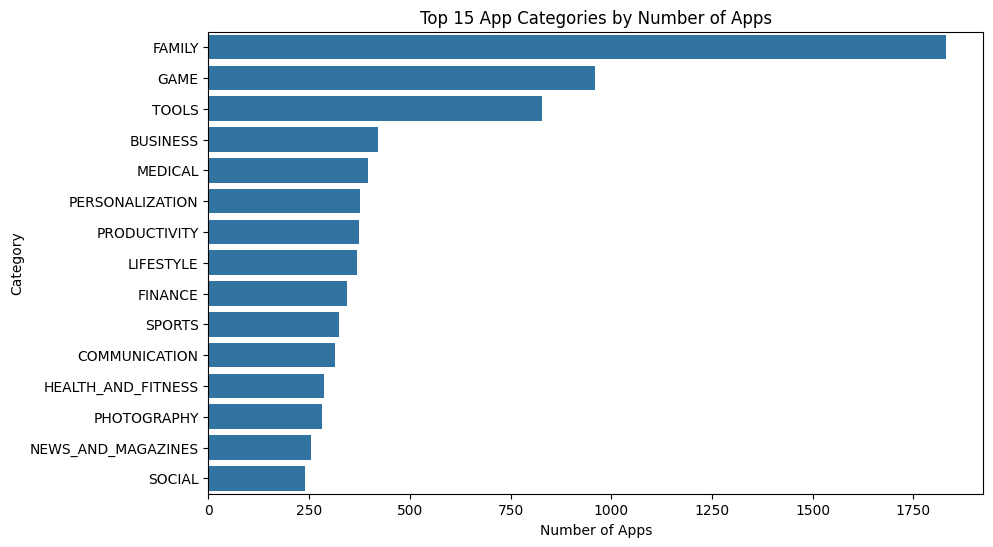

In [19]:
# Top 15 app categories

top_categories = category_counts.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 15 App Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

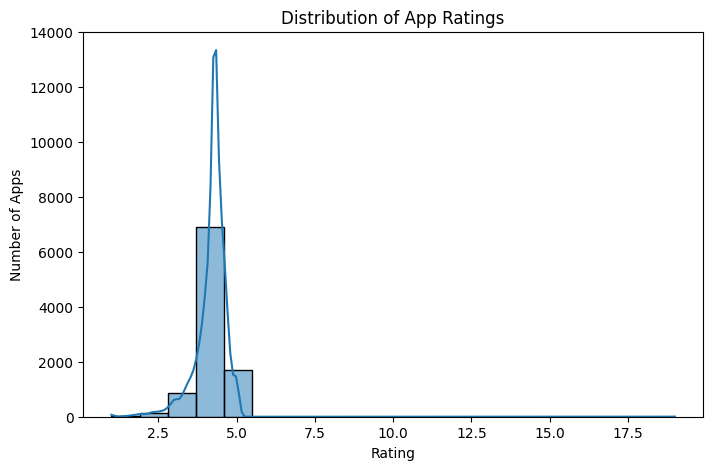

In [20]:
# Rating distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

In [21]:
# Average rating by category

avg_rating_category = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_rating_category.head(15))

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.363866
ART_AND_DESIGN          4.354687
BOOKS_AND_REFERENCE     4.334234
PERSONALIZATION         4.325532
PARENTING               4.300000
BEAUTY                  4.283019
SOCIAL                  4.255230
HEALTH_AND_FITNESS      4.251736
GAME                    4.249948
WEATHER                 4.248101
SHOPPING                4.237624
SPORTS                  4.232923
LIBRARIES_AND_DEMO      4.207143
Name: Rating, dtype: float64

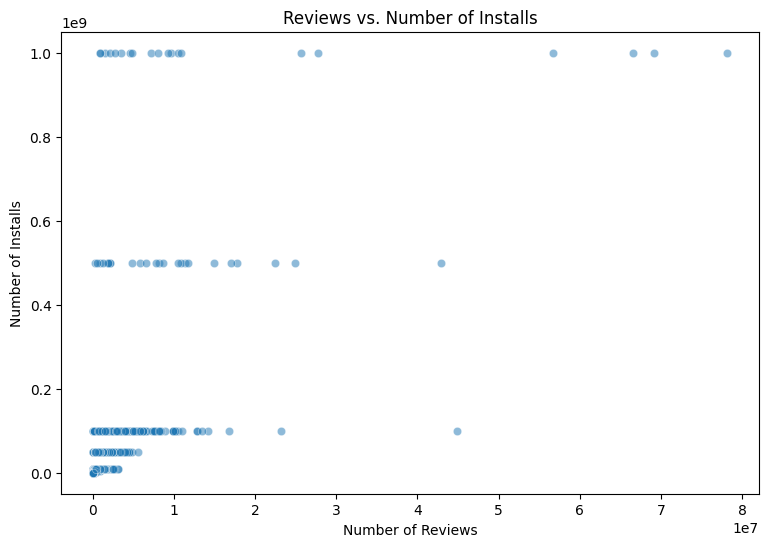

In [22]:
# Relationship between reviews and installs

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Installs",
    alpha=0.5
)

plt.title("Reviews vs. Number of Installs")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Installs")
plt.show()

In [23]:
# Top 10 apps by number of reviews

top_reviewed = (
    df[["App", "Reviews", "Category"]]
    .sort_values("Reviews", ascending=False)
    .head(10)
)

display(top_reviewed)

,App,Reviews,Category
2002,Facebook,78158306.0,SOCIAL
300,WhatsApp Messenger,69119316.0,COMMUNICATION
2003,Instagram,66577313.0,SOCIAL
299,Messenger – Text and Video Chat for Free,56642847.0,COMMUNICATION
1372,Clash of Clans,44891723.0,GAME
3181,Clean Master- Space Cleaner & Antivirus,42916526.0,TOOLS
1356,Subway Surfers,27722264.0,GAME
2908,YouTube,25655305.0,VIDEO_PLAYERS
6486,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999.0,TOOLS
1362,Clash Royale,23133508.0,GAME


Type
Free    8902
Paid     756
0          1
Name: count, dtype: int64


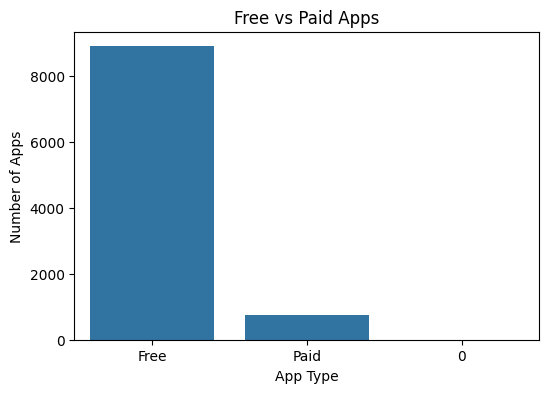

In [24]:
# Checking how many apps are free and paid

type_count = df["Type"].value_counts()

print(type_count)

plt.figure(figsize=(6, 4))
sns.barplot(x=type_count.index, y=type_count.values)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.show()

In [25]:
# Comparing ratings of free and paid apps

rating_by_type = df.groupby("Type")["Rating"].mean()

print("Average rating:")
print(rating_by_type.round(2))

Average rating:
Type
0       19.00
Free     4.19
Paid     4.27
Name: Rating, dtype: float64


In [26]:
# Total installations for each category

category_installs = (
    df.groupby("Category")["Installs"]
      .sum()
      .sort_values(ascending=False)
)

print("Top categories by total installations:")
display(category_installs.head(10))

Top categories by total installations:


Category
GAME                  1.387892e+10
COMMUNICATION         1.103828e+10
TOOLS                 8.001772e+09
PRODUCTIVITY          5.793091e+09
SOCIAL                5.487868e+09
PHOTOGRAPHY           4.649148e+09
FAMILY                4.427942e+09
VIDEO_PLAYERS         3.926903e+09
TRAVEL_AND_LOCAL      2.894887e+09
NEWS_AND_MAGAZINES    2.369218e+09
Name: Installs, dtype: float64

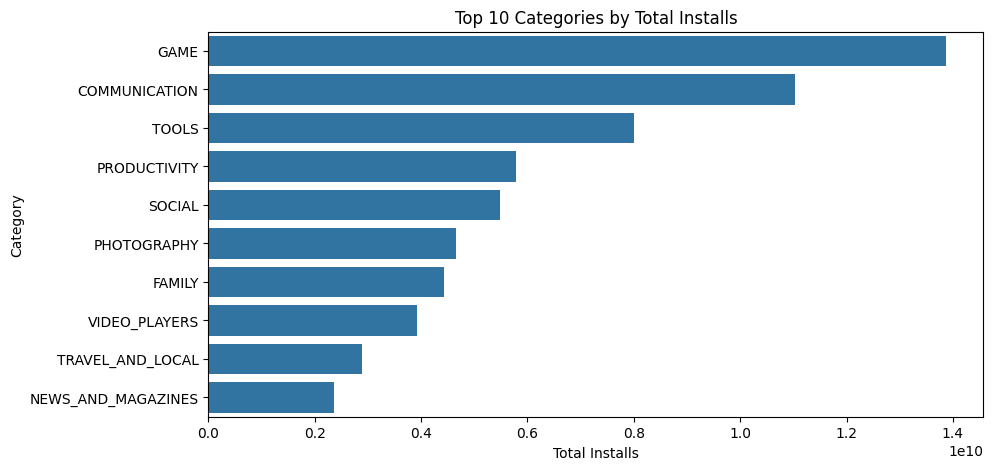

In [27]:
top_install_categories = category_installs.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_install_categories.values,
    y=top_install_categories.index
)

plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Total Installs")
plt.ylabel("Category")
plt.show()

In [28]:
# Finding the most expensive paid applications

paid_apps = df[df["Type"] == "Paid"]

expensive_apps = (
    paid_apps[["App", "Category", "Price"]]
    .sort_values("Price", ascending=False)
    .head(10)
)

display(expensive_apps)

,App,Category,Price
3469,I'm Rich - Trump Edition,LIFESTYLE,400.00
4400,I Am Rich Premium,FINANCE,399.99
4402,I am Rich!,FINANCE,399.99
4406,I Am Rich Pro,FAMILY,399.99
4398,I am Rich Plus,FAMILY,399.99
4417,I AM RICH PRO PLUS,FINANCE,399.99
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99
4413,I am Rich,FINANCE,399.99
4408,I am rich (Most expensive app),FINANCE,399.99
3327,most expensive app (H),FAMILY,399.99


Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

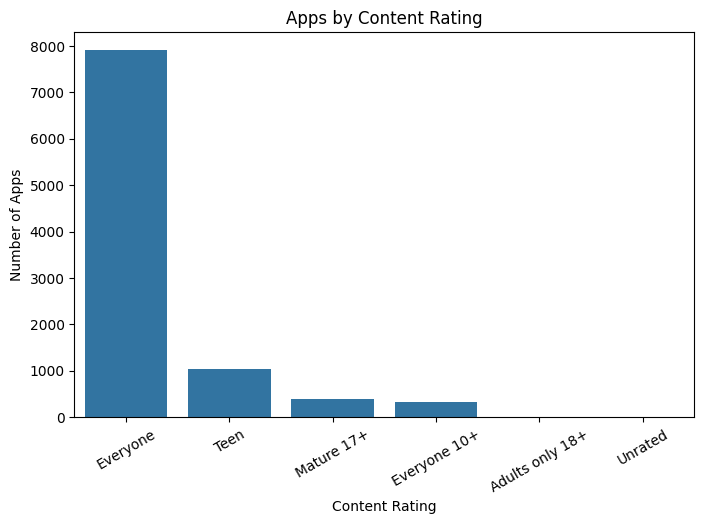

In [29]:
# Distribution of apps according to content rating

content_rating = df["Content Rating"].value_counts()

display(content_rating)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=content_rating.index,
    y=content_rating.values
)

plt.title("Apps by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.xticks(rotation=30)
plt.show()

In [30]:
genre_count = df["Genres"].value_counts()

print(genre_count.head(15))

Genres
Tools               826
Entertainment       561
Education           510
Business            420
Medical             395
Personalization     376
Productivity        374
Lifestyle           368
Finance             345
Sports              331
Communication       315
Action              299
Health & Fitness    288
Photography         281
News & Magazines    254
Name: count, dtype: int64


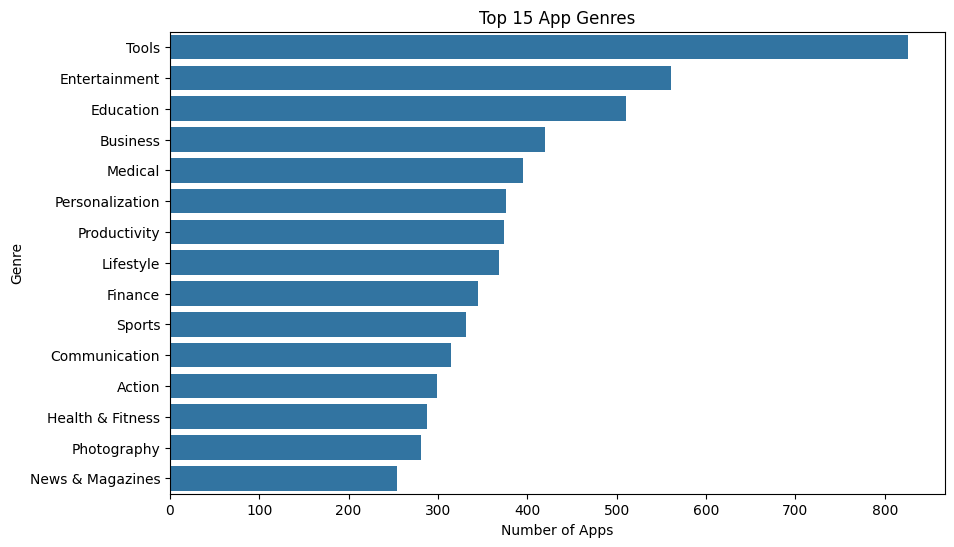

In [31]:
top_genres = genre_count.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 15 App Genres")
plt.xlabel("Number of Apps")
plt.ylabel("Genre")
plt.show()

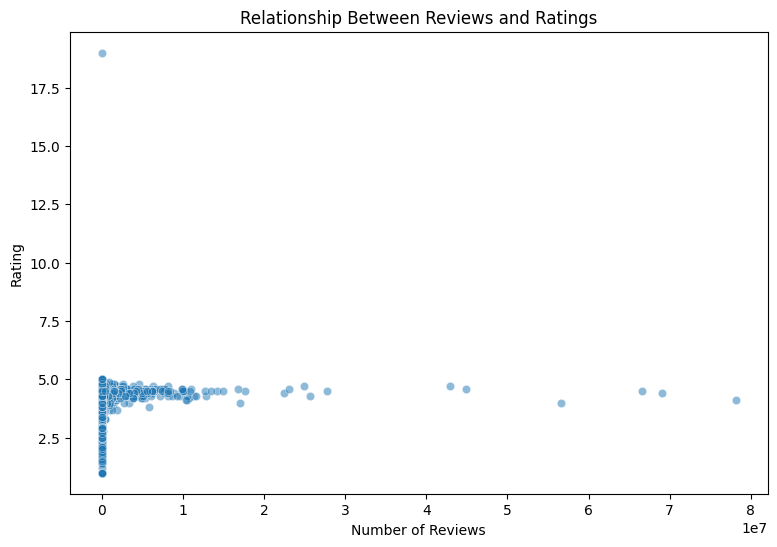

In [32]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Rating",
    alpha=0.5
)

plt.title("Relationship Between Reviews and Ratings")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.show()

In [33]:
high_rated = df[
    (df["Rating"] >= 4.5) &
    (df["Reviews"] >= 1000)
]

high_rated = high_rated[
    ["App", "Category", "Rating", "Reviews", "Installs"]
].sort_values(
    ["Rating", "Reviews"],
    ascending=[False, False]
)

display(high_rated.head(15))

,App,Category,Rating,Reviews,Installs
8490,JW Library,BOOKS_AND_REFERENCE,4.9,922752.0,10000000.0
1031,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272337.0,10000000.0
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,197136.0,1000000.0
585,"Learn Japanese, Korean, Chinese Offline & Free",EDUCATION,4.9,133136.0,1000000.0
1078,StrongLifts 5x5 Workout Gym Log & Personal Tra...,HEALTH_AND_FITNESS,4.9,66791.0,1000000.0
5963,PixPanda - Color by Number Pixel Art Coloring ...,FAMILY,4.9,55723.0,1000000.0
99,"ipsy: Makeup, Beauty, and Tips",BEAUTY,4.9,49790.0,1000000.0
3129,Hungry Hearts Diner: A Tale of Star-Crossed Souls,FAMILY,4.9,46253.0,500000.0
1029,Lose Belly Fat in 30 Days - Flat Stomach,HEALTH_AND_FITNESS,4.9,38098.0,5000000.0
4032,Solitaire: Decked Out Ad Free,GAME,4.9,37302.0,500000.0


In [34]:
category_summary = df.groupby("Category").agg(
    Apps=("App", "count"),
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Reviews", "sum"),
    Total_Installs=("Installs", "sum")
)

category_summary = category_summary.sort_values(
    "Total_Installs",
    ascending=False
)

display(category_summary.head(15).round(2))

,Apps,Average_Rating,Total_Reviews,Total_Installs
Category,,,,
GAME,959,4.25,622298709.0,1.387892e+10
COMMUNICATION,315,4.15,285811368.0,1.103828e+10
TOOLS,827,4.07,229356578.0,8.001772e+09
PRODUCTIVITY,374,4.21,55590649.0,5.793091e+09
SOCIAL,239,4.26,227927801.0,5.487868e+09
PHOTOGRAPHY,281,4.17,105351270.0,4.649148e+09
FAMILY,1832,4.19,143825488.0,4.427942e+09
VIDEO_PLAYERS,163,4.07,67484568.0,3.926903e+09
TRAVEL_AND_LOCAL,219,4.10,26819741.0,2.894887e+09


In [35]:
df.to_csv(
    "../output/googleplaystore_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Android Ver
4.1 and up            2202
4.0.3 and up          1395
4.0 and up            1285
Varies with device     990
4.4 and up             818
2.3 and up             616
5.0 and up             512
4.2 and up             372
2.3.3 and up           273
2.2 and up             239
Name: count, dtype: int64

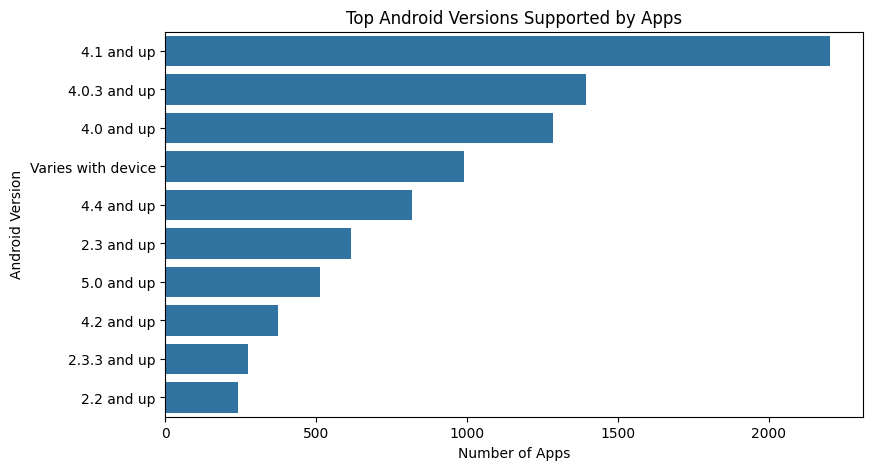

In [36]:
version_count = df["Android Ver"].value_counts().head(10)

display(version_count)

plt.figure(figsize=(9, 5))
sns.barplot(x=version_count.values, y=version_count.index)

plt.title("Top Android Versions Supported by Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Android Version")
plt.show()

In [37]:
top_apps = df[
    ["App", "Category", "Installs", "Rating"]
].sort_values(
    "Installs",
    ascending=False
).head(10)

display(top_apps)

,App,Category,Installs,Rating
2977,Google News,NEWS_AND_MAGAZINES,1.000000e+09,3.9
2012,Google+,SOCIAL,1.000000e+09,4.2
1356,Subway Surfers,GAME,1.000000e+09,4.5
152,Google Play Books,BOOKS_AND_REFERENCE,1.000000e+09,3.9
2908,YouTube,VIDEO_PLAYERS,1.000000e+09,4.3
2003,Instagram,SOCIAL,1.000000e+09,4.5
2930,Google Play Movies & TV,VIDEO_PLAYERS,1.000000e+09,3.7
2191,Google Photos,PHOTOGRAPHY,1.000000e+09,4.5
2429,Google Street View,TRAVEL_AND_LOCAL,1.000000e+09,4.2
701,Google Play Games,ENTERTAINMENT,1.000000e+09,4.3


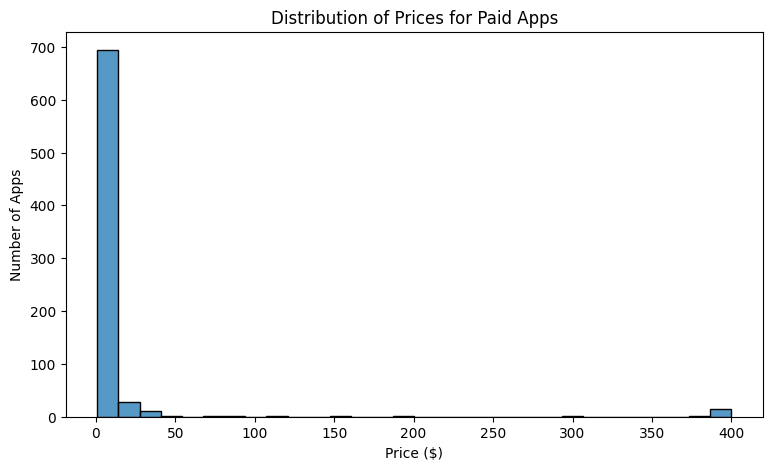

In [38]:
paid_prices = df.loc[df["Type"] == "Paid", "Price"]

plt.figure(figsize=(9, 5))
sns.histplot(paid_prices, bins=30)

plt.title("Distribution of Prices for Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.show()

Type
0       9.670000e+02
Free    2.085472e+09
Paid    6.596015e+06
Name: Reviews, dtype: float64


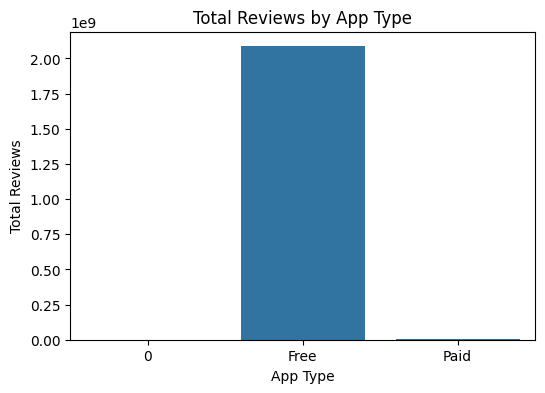

In [39]:
review_summary = df.groupby("Type")["Reviews"].sum()

print(review_summary)

plt.figure(figsize=(6, 4))
sns.barplot(x=review_summary.index, y=review_summary.values)

plt.title("Total Reviews by App Type")
plt.xlabel("App Type")
plt.ylabel("Total Reviews")
plt.show()

Category
GAME               622298709.0
COMMUNICATION      285811368.0
TOOLS              229356578.0
SOCIAL             227927801.0
FAMILY             143825488.0
PHOTOGRAPHY        105351270.0
VIDEO_PLAYERS       67484568.0
PRODUCTIVITY        55590649.0
PERSONALIZATION     53543080.0
SHOPPING            44551730.0
Name: Reviews, dtype: float64

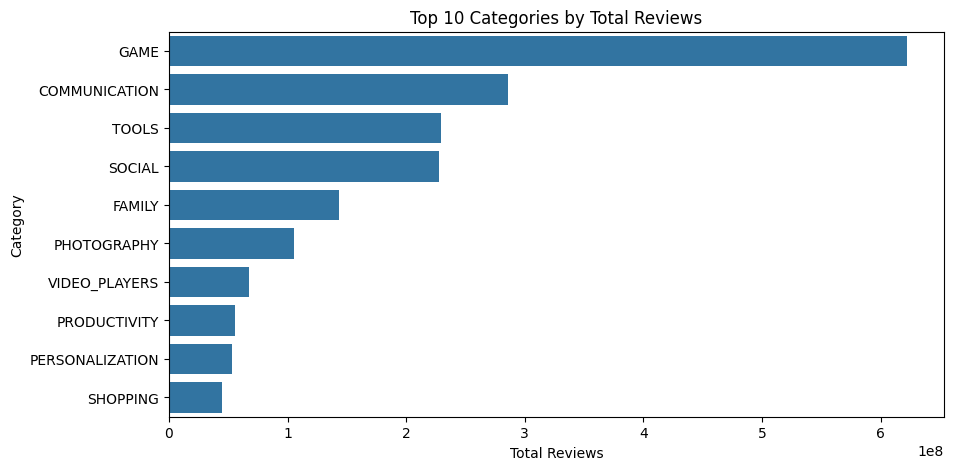

In [40]:
category_reviews = (
    df.groupby("Category")["Reviews"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(category_reviews)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_reviews.values,
    y=category_reviews.index
)

plt.title("Top 10 Categories by Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Category")
plt.show()

## Key Insights

- The Play Store contains apps from a wide range of categories, with some categories having a much larger number of applications than others.
- Free applications make up a large portion of the dataset compared with paid applications.
- Ratings are generally concentrated around the higher end of the rating scale.
- Apps with a larger number of reviews generally represent stronger user engagement.
- Installation counts vary considerably across categories and applications.
- The number of reviews and installations can provide useful indicators of app popularity.
- Paid applications show a wide variation in pricing.
- Content rating analysis shows that apps target different user groups.
- Category-level analysis helps identify areas with high application availability and user engagement.

## Business Recommendations

1. Focus on categories with high installation and review activity when planning new apps.

2. Use ratings and review counts together to understand user satisfaction and engagement.

3. Keep the app experience simple and reliable because user ratings can strongly influence an app's visibility and reputation.

4. For paid applications, pricing should be considered along with reviews, ratings, and installation levels.

5. Developers can study highly installed applications to understand common features and user preferences.

6. Regularly monitoring reviews and ratings can help identify areas where an application can be improved.

## Conclusion

This project analyzed Google Play Store applications to understand app categories, ratings, reviews, installations, pricing, genres, and content ratings.

The dataset was cleaned by handling duplicate applications, converting numerical columns into suitable formats, and managing missing values.

Exploratory data analysis and visualizations were used to identify patterns in app popularity, user engagement, ratings, and installations. The analysis also compared free and paid applications and examined category-level performance.

The results provide useful insights into application popularity and user engagement. These insights can help developers and businesses understand the Play Store ecosystem and make data-driven decisions when planning, improving, or evaluating mobile applications.

In [41]:
summary = category_summary.reset_index()

summary.to_csv(
    "../output/category_performance_summary.csv",
    index=False
)

print("Analysis results saved successfully.")

Analysis results saved successfully.


In [42]:
print("Google Play Store Analysis")
print("-" * 35)

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nAnalysis completed:")
print("1. Data cleaning")
print("2. Category analysis")
print("3. Rating analysis")
print("4. Review and installation analysis")
print("5. Free vs paid analysis")
print("6. Price analysis")
print("7. Genre analysis")
print("8. Content rating analysis")
print("9. Business insights")

print("\nProject completed successfully!")

Google Play Store Analysis
-----------------------------------
Dataset shape: (9660, 14)
Missing values: 15
Duplicate rows: 0

Analysis completed:
1. Data cleaning
2. Category analysis
3. Rating analysis
4. Review and installation analysis
5. Free vs paid analysis
6. Price analysis
7. Genre analysis
8. Content rating analysis
9. Business insights

Project completed successfully!
